# Time Series Forecasting with TorchGeo: Air Quality Tutorial

In this tutorial, we demonstrate how to train a multivariate time series forecasting model using TorchGeo. Univariate ($\mathbb{R}^{T}$) and multivariate ($\mathbb{R}^{T \times C}$) regression form the foundation of time series analysis and have a wide range of applications in Earth science, from direct physical sensor measurements to remote sensing products and socio-environmental indices.

Time series in Earth science can be modeled using a spectrum of approaches. Classical stochastic methods, such as ARIMA and state-space models, explicitly encode temporal dependence through statistical structure. In contrast, modern deep learning architectures either generate forecasts autoregressively (e.g., RNNs, decoder-style Transformers) or learn representations of entire temporal windows as contextual embeddings (e.g., TempCNN, LTAE, encoder-based Transformers).

In this tutorial, we train the LTAE encoder model on the UCI Air Quality dataset to forecast concentrations of major pollutants. Specifically, we use the last 24 hours of readings from the sensor channels `CO(GT)`, `C6H6(GT)`, `NOx(GT)`, and `NO2(GT)` to predict the next hour for all channels simultaneously.

This tutorial introduces three TorchGeo components designed for time series analysis: the dataset `AirQuality` / `AirQualityDataModule`, the `LTAE` model, and the Lightning module `TemporalRegressionTask`, each of which is explained in detail in the following sections.

## Imports

First, we import TorchGeo and the supporting lightning libraries. `L.seed_everything` fixes the random seed for weight initialisation, data shuffling, and dropout, ensuring that results are fully reproducible across runs.

In [94]:
import lightning as L
from torchgeo.datasets import AirQuality
from torchgeo.datamodules import AirQualityDataModule
from torchgeo.trainers import TemporalRegressionTask
from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
L.seed_everything(0, workers=True)

Seed set to 0


0

## The UCI Air Quality Dataset

The `AirQuality` dataset contains 15 attributes measured hourly for approximately 13 months at a roadside station in Italy (March 2004-February 2005). The channels include time information (date and hour), analyser measurements of pollutant concentrations (CO, NMHC, benzene, NOx, NO₂), alongside metal-oxide sensor responses that act as indirect proxies, and meteorological variables (temperature, relative humidity, absolute humidity).

For our analysis, we use the following configuration: We set the `input_steps` to 24 to reflect a 1-day input window and `target_steps` to 1 to predict the next hour. As `input_features`, we select the four target gases of interest, in addition to the meteorological variables and time information. These are intended to provide additional context to increase the model’s predictive power, while for `target_features` we only select the features to be predicted. `AirQuality` encodes both time variables into their respective sinusoidal representations. 

Missing values, encoded as `-200` in the raw data, are handled automatically by `AirQuality` via linear interpolation. We exclude the `NMHC(GT)` channel for our analysis, which contains predominantly missing values.

We download the dataset and apply our configuration. The built-in `plot()` function allows us to visualize a single sample, showing the input time series and the target values to be predicted for each target feature. 

The varying scales across features suggest the need for normalization, which is handled by the `AirQualityDataModule`, as explained subsequently.

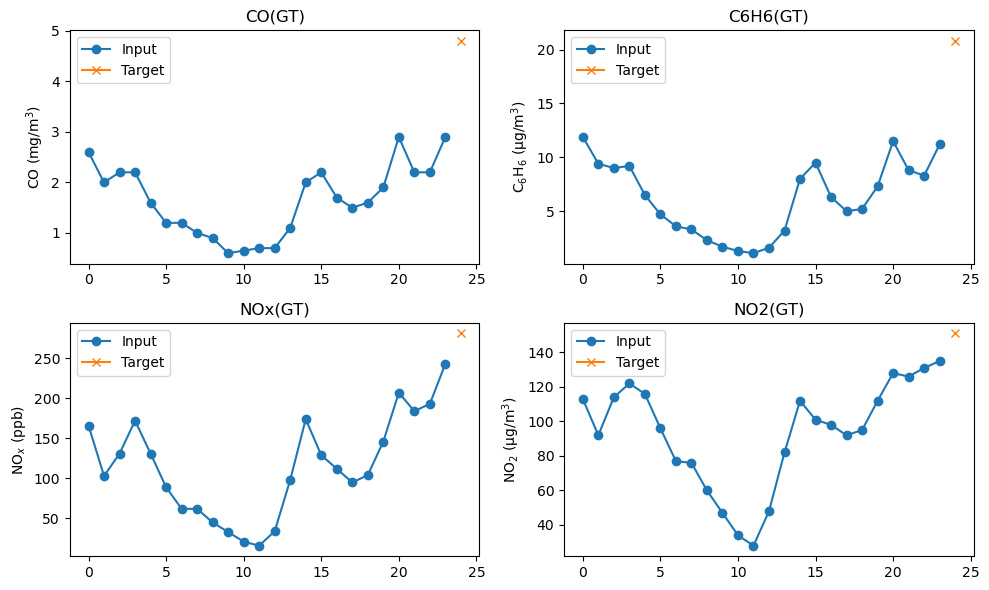

In [95]:
CONFIG = dict(
    root="data",
    download=True,
    input_steps=24,
    target_steps=1,
    input_features=["Date", "Time", "T", "RH", "AH", "CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"],
    target_features=["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"],
)
dataset = AirQuality(**CONFIG)
fig = dataset.plot(dataset[0], features =CONFIG["target_features"])

## Lightning Modules

TorchGeo uses PyTorch Lightning to organise training code and set up data loaders. `AirQualityDataModule` handles loading, normalisation, and splitting in one place: It downloads the data if not already present, splits the dataset chronologically into train (70%), validation (15%), and test (15%) subsets, and applies per-feature z-score normalisation, with mean and standard deviation computed from the training set.

**Why chronological splitting?** In time series, a random split could cause *temporal leakage*: the model would implicitly see future observations during training (embedded in shuffled batches), artificially inflating evaluation metrics. By splitting in strict time order, earliest data for training, most recent for testing, we obtain an honest estimate of how well the model generalises to unseen future conditions.

**Why fit normalisation only on the training set?** Computing statistics on the full dataset would *leak distributional information* about the validation and test periods into preprocessing. Fitting z-score parameters on training data only ensures that the held-out sets are normalised using only information that would be available in deployment.


In [96]:
dm = AirQualityDataModule(
    **CONFIG,
    val_split_pct=0.15,
    test_split_pct=0.15,
)

## Task and Model

We train the model using the `TemporalRegressionTask`, which wraps an L-TAE encoder with a regression head and handles optimisation and evaluation.

The **Lightweight Temporal Attention Encoder (L-TAE; Garnot & Landrieu, 2020)** serves as the backbone. Unlike recurrent models such as LSTMs, L-TAE does not process timesteps sequentially. Instead, it applies multi-head attention over the entire temporal sequence at once, producing a fixed-size embedding regardless of sequence length. This way, the model enables global temporal aggregation while avoiding the vanishing-gradient issues of RNN-based architectures.

The resulting embedding is passed to a lightweight regression head, which maps the latent representation to the desired prediction space. Dropout is applied with probability `0.2` for regularisation.

#### L-TAE model architecture

| Parameter     | Description                                                                                               |
| ------------- | --------------------------------------------------------------------------------------------------------- |
| `in_channels` | Number of channels of the input embeddings (Each temporal feature needs 2 channels due to the sinusoidal encodings)                                                                                                                  |
| `n_head`      | Number of attention heads                                                                                 |
| `n_neurons`   | Dimensions of the successive feature spaces of the MLP that processes concatenated attention head outputs |
| `dropout`     | Dropout rate applied within the encoder                                                                   |                                                                   
| `len_max_seq` | Maximum sequence length used to pre-compute the positional encoding table                                 |                                           
| `d_model`     | Input is projected via a fully connected layer into a feature space of dimension `d_model`       |

#### TemporalRegressionTask configuration

| Parameter     | Description                                |
| ------------- | ------------------------------------------ |
| `num_outputs` | Number of predicted target variables       |
| `labels`      | Names of target variables                  |
| `out_steps`   | Number of future timesteps predicted       |
| `loss`        | Training loss computed in normalised space |
| `lr`          | AdamW learning rate                        |
| `len_max_seq` | Maximum input sequence length              |


During training, the task encodes input sequences using the L-TAE encoder, projects the resulting embedding through the regression head, and optimises mean squared error in normalised space. Evaluation metrics (RMSE and MAE) are reported after denormalisation and in physical units.



In [98]:
task = TemporalRegressionTask(
    model="ltae",
    n_head=16,
    d_model=256,
    n_neurons=(256, 128),
    dropout=0.2,
    in_channels=11,
    num_outputs=len(CONFIG["target_features"]),
    labels=CONFIG["target_features"],
    out_steps=CONFIG["target_steps"],
    loss="mse",
    lr=3e-4,
    len_max_seq=CONFIG["input_steps"],
)

## Training

We train the model for `50` epochs using Lightning's `Trainer`, configured with three components:

**`TensorBoardLogger`**: records training and validation loss at every epoch to a local `tb_logs/` directory. TensorBoard reads these logs and renders interactive plots.

 **`ModelCheckpoint`**: saves the model weights corresponding to the lowest validation loss observed during training. 

**`EarlyStopping`**: monitors validation loss and halts training automatically if it fails to improve for `15` consecutive epochs.



In [99]:
trainer = Trainer(
    max_epochs=50,
    logger=TensorBoardLogger("tb_logs", name="air_quality"),
    callbacks=[
        ModelCheckpoint(monitor='val_loss', mode='min', save_top_k=1),
        EarlyStopping(monitor='val_loss', patience=15, mode='min'),
    ],
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


`trainer.fit(task, datamodule=dm)` starts the full PyTorch Lightning training loop using the defined task and datamodule. This call handles the entire pipeline, including data loading, forward/backward passes, validation at the end of each epoch, and integration with logging, checkpointing, and early stopping as configured in the Trainer.

In [100]:
trainer.fit(task, datamodule=dm)


  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | Sequential       | 312 K  | train
1 | criterion     | MSELoss          | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | val_metrics   | MetricCollection | 0      | train
4 | test_metrics  | MetricCollection | 0      | train
-----------------------------------------------------------
312 K     Trainable params
0         Non-trainable params
312 K     Total params
1.250     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/fschi/miniconda3/envs/torchgeo-dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=17` in the `DataLoader` to improve performance.


/home/fschi/miniconda3/envs/torchgeo-dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=17` in the `DataLoader` to improve performance.


Epoch 31: 100%|██████████| 101/101 [00:03<00:00, 26.86it/s, v_num=26]


## Inspecting Training with TensorBoard

The cell below starts TensorBoard inside the notebook environment. It reads the event logs saved in tb_logs/ during training and provides an interactive dashboard to monitor training and validation metrics (and any logged test metrics).


In [ ]:
%load_ext tensorboard
%tensorboard --logdir tb_logs

## Evaluation
`trainer.test()` automatically restores the best checkpoint saved by `ModelCheckpoint` and runs a single forward pass over the held-out test set.

In [101]:
trainer.test(task, datamodule=dm)

/home/fschi/miniconda3/envs/torchgeo-dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=17` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 22/22 [00:00<00:00, 54.09it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test_MAE_C6H6(GT)     │    3.3413875102996826     │
│      test_MAE_CO(GT)      │    0.6822635531425476     │
│     test_MAE_NO2(GT)      │    44.127811431884766     │
│     test_MAE_NOx(GT)      │     74.8550033569336      │
│     test_MSE_C6H6(GT)     │    23.239774703979492     │
│      test_MSE_CO(GT)      │    0.8925043940544128     │
│     test_MSE_NO2(GT)      │     3488.89404296875      │
│     test_MSE_NOx(GT)      │      10786.240234375      │
│    test_RMSE_C6H6(GT)     │     4.820765018463135     │
│     test_RMSE_CO(GT)      │    0.9447245001792908     │
│     test_RMSE_NO2(GT)     │     59.06686019897461     │
│     test_RMSE_NOx(GT)     │    103.85682678222656     │
│         test_loss         │    0.2539038360118866     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.2539038360118866,
  'test_MAE_CO(GT)': 0.6822635531425476,
  'test_MAE_C6H6(GT)': 3.3413875102996826,
  'test_MAE_NOx(GT)': 74.8550033569336,
  'test_MAE_NO2(GT)': 44.127811431884766,
  'test_MSE_CO(GT)': 0.8925043940544128,
  'test_MSE_C6H6(GT)': 23.239774703979492,
  'test_MSE_NOx(GT)': 10786.240234375,
  'test_MSE_NO2(GT)': 3488.89404296875,
  'test_RMSE_CO(GT)': 0.9447245001792908,
  'test_RMSE_C6H6(GT)': 4.820765018463135,
  'test_RMSE_NOx(GT)': 103.85682678222656,
  'test_RMSE_NO2(GT)': 59.06686019897461}]

The **test_loss** is the **MSE (Mean Squared Error)** computed in the *z-score-normalised space* shared across all channels. A value below **1.0** indicates that the model’s average squared error per normalised channel is smaller than the variance of that channel in the training set, meaning the model, with a value of **0.25** performs better than a naïve baseline that predicts the channel mean at every timestep.

The **MAE (Mean Absoulte Error)** and **RMSE (Root Mean Squared Error)** metrics are computed after inverting the z-score normalisation, so they are expressed in the **original physical units** of the sensor readings. This makes them directly interpretable per pollutant and allows comparison across features in real-world terms.

**MAE** reflects the average absolute deviation from the true value (e.g., for CO, about **0.68 mg/m³** on average) and should be interpreted relative to the typical magnitude and variability of each individual feature.


## Summary

This tutorial shows how TorchGeo provides a unified interface for time series learning tasks by building a multivariate time series forecasting pipeline on the UCI Air Quality dataset. The goal was to predict next-hour pollutant concentrations using the previous 24 hours of sensor observations.

We combined three main components: the `AirQuality` dataset and `AirQualityDataModule` for loading, preprocessing, chronological splitting, and normalization; the Lightweight Temporal Attention Encoder (L-TAE) as a global attention-based sequence encoder; and the `TemporalRegressionTask`, which wraps the model into a full training and evaluation pipeline. The model was trained using mean squared error in normalized space, while evaluation metrics (MAE and RMSE) were reported in physical units for interpretability. 

## To Go Further

There are many extensions to this tutorial that can help you explore different modelling choices, forecasting setups, and datasets. Below are a few directions to try next:

**Adjust the forecasting horizon**: decrease `input_steps` and `target_steps` for short-term nowcasting (e.g. 6 hours of context → 1-hour forecast), or increase them for long-context environmental modelling over multiple days (e.g. 144 hours → 24-hour forecast).

**Experiment with feature sets**: try different combinations of input and target features to study how meteorological variables and pollutant channels affect forecasting performance.

**Compare encoder architectures**: replace L-TAE with alternative temporal models such as convolution-based encoders like `TempCNN`.

**Apply to other datasets**: the `TemporalRegressionTask` is dataset-agnostic. You can plug in any dataset that returns `(input, target)` tensors to benchmark the same pipeline on other forecasting tasks.
